In [98]:
import numpy as np
import matplotlib.pyplot as plt
import jax.random as jrd
import jax.numpy as jnp
import optax
from evoscape.landscapes import Landscape
from evoscape.modules import Node, UnstableNode
from evoscape.landscape_visuals import *
from evoscape.jax import pytree_to_landscape
from evoscape.morphogen_regimes import mr_const, mr_piecewise, mr_sigmoid
from evoscape.jax.dynamics import get_cell_states
from evoscape.jax.losses import origin_leading_fitness, biseparating_fitness
from evoscape.jax.experiment import Experiment
from evoscape.jax.utils import init_cell, make_movie_landscape
from jax.scipy.special import kl_div, entr
plt.style.use('default')
plt.rcParams.update({'figure.dpi': 100})
plt.rcParams.update({'font.size': 15})

%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [99]:
# Landscape with one regime + simple visualization
%autoreload

# Definition of the modules of the landscape: to be constructed accordingly

# M1 = Node(x=-1.5, y=0., a=1.5, s=1.)
# M2 = Node(x=3., y=0., a=2., s=0.8)

# M1 = Node(x=-0.5, y=0., a=1.5, s=1.)
# M2 = Node(x=1., y=0., a=1.5, s=1.)

# M1 = Node(x=-0.5, y=0., a=[1.5,5.], s=[1.,1.])
# M2 = Node(x=0.5, y=0., a=[1.5,5.], s=[1.,1.])

# M1 = Node(x=-0.5, y=0., a=[1.5,5.], s=[1.,1.], tau=1.)
# M2 = Node(x=0.5, y=0., a=[1.5,5.], s=[1.,1.], tau=1.)

#Biseparation
M1 = Node(x=-0.5, y=0., a=1.5, s=1.)
M2 = Node(x=0.5, y=0., a=2., s=0.8)

# M1 = UnstableNode(x=0., y=0., a=2., s=1.)
# M2 = Node(x=1., y=0., a=0.5, s=0.8)

module_list = [M1, M2]


# M1 = Node(x=-3., y=0., a=3., s=1.)
# M2 = Node(x=4., y=0., a=3., s=1.)
# M3 = Node (x= 2., y= 3., a= 3.,s=1.)

# module_list = [M1, M2, M3]

# Definition of the landscape
# landscape = Landscape(module_list, A0 = 0.01, regime=mr_const, n_regimes=2)
# landscape = Landscape(module_list, A0 = 0.01, regime=mr_piecewise, n_regimes=2, morphogen_times=(5.,))
# landscape = Landscape(module_list, A0 = 0.01, regime=mr_sigmoid, n_regimes=2, morphogen_times=(5.,))
landscape = Landscape(module_list, A0 = 0.01, regime=mr_const, n_regimes=2)
print(landscape)


#Numerical constants for simulation
n, init_cond, init_noise, t0,tf, nt, ndt, noise, lr, steps=200, jnp.array([0.,1.]), 0.5, 0., 10., 51, 50, 0.5, 0.01, 400

q_init = jnp.tile(init_cond[:, None], (1, n))

# Selection of the get_states function 
get_states = get_cell_states

T, μ, λ, q_prob =1., 5., 1., (0.5,0.5)

loss_params = T, μ, λ, q_prob
# fitness = biseparating_fitness
fitness = origin_leading_fitness

# For signal regime
signal_param = None

opt = optax.adam(lr)

Landscape with modules:
Node: x=-0.5; y=0.0; a=1.5; s=1.,
Node: x=0.5; y=0.0; a=2.; s=0.8


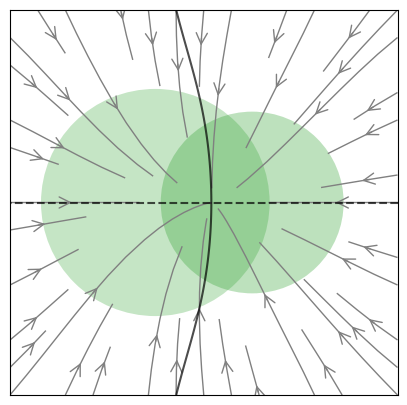

In [100]:
# Parameters of vizualisation 
L = 2.
npoints = 201
q = np.linspace(-L, L, npoints)
xx, yy = np.meshgrid(q, q, indexing='xy')

fig = visualize_landscape(landscape, xx, yy, regime=0, color_scheme='fp_types')

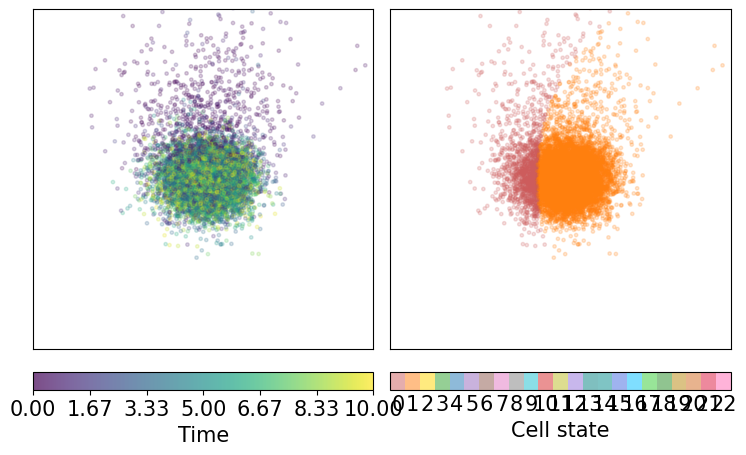

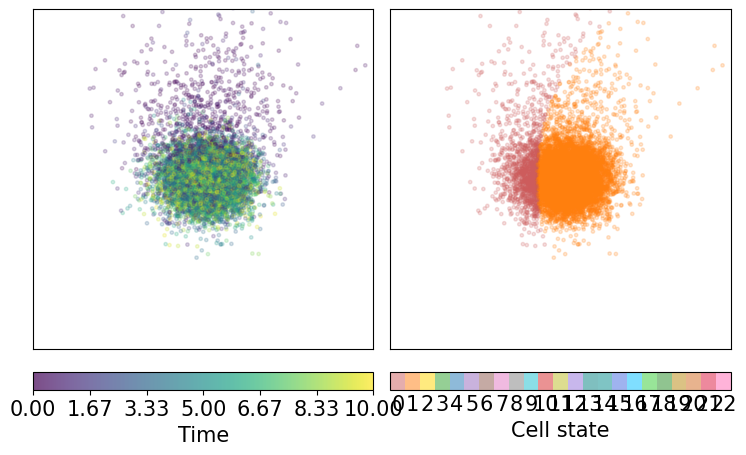

In [101]:
landscape.init_cells(n,landscape.init_cond,noise=init_noise)
get_and_plot_traj(landscape,t0,tf,nt,L,noise)

In [102]:
# n_frames = 100
# time_pars = (t0,tf, n_frames)
# print(landscape.n_regimes)
# labels = [f"regime {i}" for i in range(0,landscape.n_regimes+1)]
# print(labels)
# make_movie_discrete(landscape, xx, yy, labels, time_pars, n, noise, init_cond=landscape.init_cond,
#                         circles=True, circle_opacity=0.1, density=0.65, nullclines=False,
#                         fps=10, save_dir='../figures/', filename='start_traj.gif')

# save_dir = '../temp/figures/'
# import os, glob
# for f in glob.glob(save_dir + "frame_*.png"):
#     os.remove(f)

In [103]:
pytree = Experiment(landscape = landscape)

print(pytree.dynamic)
pytree.set_initial_conditions(q_init= q_init)
#We should depreciate set_regime as It shouldn't have to be set manually
pytree.set_regime_params(signal_param = signal_param)

pytree.set_simulation(n=n, init_noise=init_noise,t0=t0, tf=tf, nt= nt, ndt= ndt, noise=noise)

pytree.set_state_probs(get_cell_states=get_states)

# losses = pytree.optimize(user_fitness=fitness, fitness_params=loss_params, steps=steps, lr= lr)

losses = pytree.optimize(user_fitness=fitness, fitness_params=loss_params, steps=steps, optimizer=opt)

dynamic, static, traj, states = pytree.dynamic, pytree.static, pytree.trajectories, pytree.states

LandscapeDynamic(module=ModuleDynamic(x=Array([-0.5,  0.5], dtype=float32), y=Array([0., 0.], dtype=float32), a=Array([1.5, 2. ], dtype=float32), s=Array([1. , 0.8], dtype=float32)))
Train step 0 : Loss = 25.116498947143555


KeyboardInterrupt: 

In [ ]:
print(dynamic)

LandscapeDynamic(module=ModuleDynamic(x=Array([-0.7602735 , -0.03840812], dtype=float32), y=Array([-0.6377707 , -0.03790418], dtype=float32), a=Array([1.4881872, 1.6724362], dtype=float32), s=Array([0.40711337, 1.3949605 ], dtype=float32)))


In [ ]:
print(jnp.mean(states[:,-1]))

0.755


In [ ]:
final_coord = traj[:,:,-1]

module_coord = jnp.stack((dynamic.module.x,dynamic.module.y))
m = module_coord.shape[1]
dist_squared = jnp.sum((final_coord.T[:, :, None] - module_coord)**2, axis=1)

weights = jnp.exp(-dist_squared / T)

P = weights / (jnp.sum(weights, axis=1, keepdims=True))

p_j = jnp.mean(P, axis=0)

loss_uniform = jnp.mean(kl_div(p_j,jnp.array(q_prob)))

uniform = jnp.ones_like(P) / P.shape[1]

loss_particle = -jnp.mean(
    jnp.sum(kl_div(P, uniform), axis=1)
)

print(P[:5,:], μ * loss_uniform, λ * loss_particle, losses[-1], jnp.mean(jnp.argmax(P,axis=1)))

[[0.40376464 0.59623545]
 [0.195976   0.80402404]
 [0.15458657 0.84541345]
 [0.4094345  0.59056544]
 [0.22614671 0.7738533 ]] 0.2660711 -0.12857214 30.906986 0.96999997


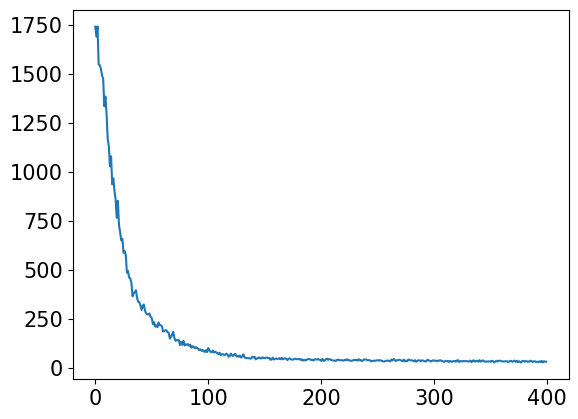

In [ ]:
plt.plot(losses)

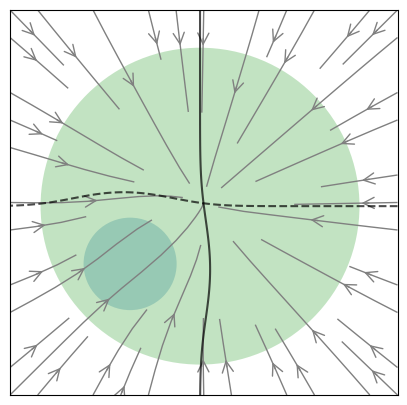

In [ ]:
l = pytree.get_landscape()
fig = visualize_landscape(l, xx, yy, regime=0, color_scheme='fp_types')

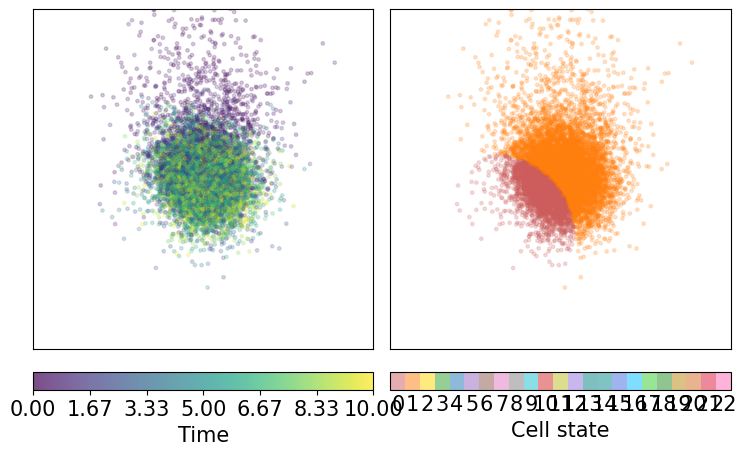

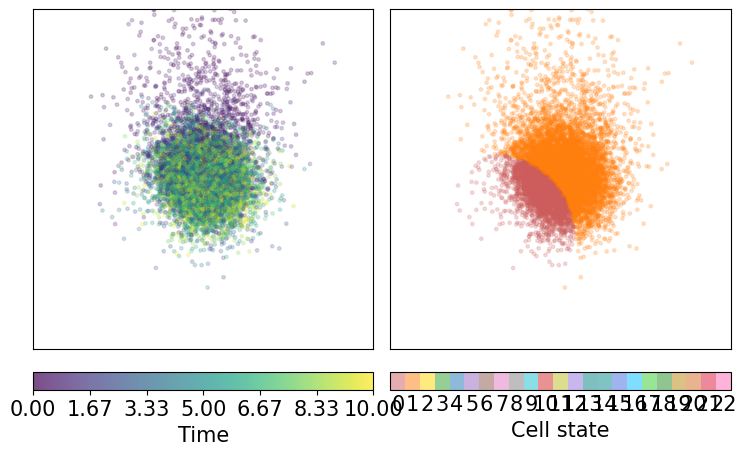

In [ ]:
# Put back the coordinates of the cells at the init_ as the are
l.init_cells(n,static.init_cond,noise=init_noise)
get_and_plot_traj(l,t0,tf,nt,L,noise) 

In [ ]:
n_frames = 100
time_pars = (t0,tf, n_frames)
labels = [f"regime {i}" for i in range(0,l.n_regimes)]
make_movie_discrete(l, xx, yy, labels, time_pars, n, noise, init_cond=l.init_cond,
                        circles=True, circle_opacity=0.1, density=0.65, nullclines=False,
                        fps=10, save_dir='../temp/figures/', filename='end_traj_prez.gif')

save_dir = '../temp/figures/'
import os, glob
for f in glob.glob(save_dir + "frame_*.png"):
    os.remove(f)

Movie saved to ../temp/figures/end_traj_prez.gif


In [ ]:
n_frames = steps//4
make_movie_landscape(pytree.dynamic_vals,static, xx, yy, n_frames,"../temp/figures/animation_prez.gif")